<a href="https://colab.research.google.com/github/snehubhosle/CSI_Weekly_Assignments/blob/main/Shopping_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1. Basic Data Exploration and Cleaning using Pandas**

**Objective: Learn Python basics and perform basic data exploration and cleaning using Pandas.**

#Steps:
1.Load a CSV dataset into a Pandas DataFrame.
2.Explore data (head/tail, shape, columns, data types).
3.Handle missing values (identify, fill/drop).
4.Perform basic operations (filter rows, select columns).
5.Remove duplicates.
6.Create a derived column (total_amount = price * quantity).
7.Save the cleaned dataset as a new CSV file.

# Output:
Jupyter Notebook (.ipynb) + cleaned CSV + brief summary.""" "# Shopping Dataset Assignment Guide

# **1. Objective**

 Perform exploratory data analysis (EDA), data cleaning, and derive meaningful insights from the combined dataset.

# **2. Dataset to Use**

Use the **combined_dataset.csv** file, as it contains all relevant product-level information required for the assignment.




# **3. Steps to Follow**


**Step 1: Load Data:**
Import required libraries and load the dataset.

In [ ]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set(style='whitegrid')

def load_dataset(preferred_path=None):
    """Load dataset from Colab or local path."""
    try:
        from google.colab import files
        print('Uploading from Colab...')
        uploaded = files.upload()
        fname = next(iter(uploaded))
        return pd.read_csv(io.BytesIO(uploaded[fname]), low_memory=False)
    except Exception:
        if preferred_path and os.path.exists(preferred_path):
            return pd.read_csv(preferred_path, low_memory=False)
        alt = os.path.join('archive(2)', 'Combined_dataset.csv')
        if os.path.exists(alt):
            return pd.read_csv(alt, low_memory=False)
        raise FileNotFoundError('Dataset not found.')

df = load_dataset()
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns[:5])}... and {len(df.columns) - 5} more')

Uploading from Colab...


Saving Combined_dataset.csv to Combined_dataset.csv
Loaded: 1000 rows × 24 columns
Columns: ['product_id', 'title', 'product_description', 'rating', 'ratings_count']... and 19 more


**Step 2: Understand Data:**
Examine data types, missing values, and summary statistics.

In [ ]:
print('Data Types:')
print(df.dtypes)
print('\n' + '='*50)

print('\nMissing Values (%)')
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False).head(15)
for col, pct in missing_pct.items():
    print(f'{col}: {pct:.1f}%')

print('\nBasic Statistics:')
display(df.describe(include=[np.number]).T)

Data Types:
product_id                  int64
title                      object
product_description        object
rating                    float64
ratings_count               int64
initial_price               int64
discount                  float64
final_price                object
currency                   object
images                     object
delivery_options           object
product_details            object
breadcrumbs                object
product_specifications     object
amount_of_stars            object
what_customers_said        object
seller_name                object
sizes                      object
videos                     object
seller_information         object
variations                 object
best_offer                 object
more_offers                object
category                   object
dtype: object


Missing Values (%)
videos: 78.1%
what_customers_said: 57.3%
variations: 56.2%
seller_name: 30.1%
seller_information: 30.1%
discount: 12.1%

Basic Statistics

,count,mean,std,min,25%,50%,75%,max
product_id,1000.0,1.713437e+07,3.813766e+06,586846.0,15115009.5,18208901.0,19027372.0,22747068.0
rating,1000.0,3.621500e+00,1.374400e+00,0.0,3.7,4.1,4.3,5.0
ratings_count,1000.0,7.669100e+01,2.411143e+02,0.0,7.0,17.0,58.0,4441.0
initial_price,1000.0,2.723241e+03,2.408697e+03,249.0,1399.0,1999.0,3299.0,22199.0
discount,879.0,5.350398e+01,1.802920e+01,1.0,44.0,56.0,66.0,88.0


**Step 3: Data Cleaning:**
Handle missing values, convert data types, remove duplicates.

In [ ]:
def coerce_numeric(series):
    """Convert string/mixed columns to numeric."""
    s = series.astype(str).str.strip().replace({'': None, 'nan': None})
    s = s.str.replace(r'[^0-9\\.\\-]', '', regex=True)
    return pd.to_numeric(s, errors='coerce')

numeric_cols = ['initial_price', 'final_price', 'discount', 'rating', 'ratings_count']
for col in numeric_cols:
    if col in df.columns:
        df[col] = coerce_numeric(df[col])

if 'ratings_count' in df.columns:
    df['ratings_count'] = df['ratings_count'].fillna(0).astype(int)
if 'rating' in df.columns:
    df['rating'] = df['rating'].fillna(df['rating'].median())

before = len(df)
df.drop_duplicates(inplace=True)
if 'product_id' in df.columns:
    df.drop_duplicates(subset=['product_id'], inplace=True)
after = len(df)

print(f'Duplicates removed: {before - after}')
print(f'Final shape: {df.shape}')

Duplicates removed: 0
Final shape: (1000, 24)


**Step 4: Feature Engineering:**
Create new features: price difference, discount %, popularity score.

In [ ]:
for col in ['initial_price', 'final_price']:
    if col not in df.columns:
        df[col] = np.nan

df['price_difference'] = df['initial_price'] - df['final_price']
df['discount_pct'] = np.where(
    df['initial_price'] > 0,
    (df['price_difference'] / df['initial_price']) * 100,
    np.nan
)
df['popularity_score'] = df['rating'].fillna(0) * df['ratings_count'].fillna(0)

print('Features created: price_difference, discount_pct, popularity_score')
cols = ['initial_price', 'final_price', 'price_difference', 'discount_pct', 'popularity_score']
cols = [c for c in cols if c in df.columns]
display(df[cols].head())

Features created: price_difference, discount_pct, popularity_score


,initial_price,final_price,price_difference,discount_pct,popularity_score
0,3995,3995.0,0.0,0.0,57.0
1,2899,2899.0,0.0,0.0,301.5
2,2999,2999.0,0.0,0.0,994.4
3,1675,1675.0,0.0,0.0,4628.8
4,2899,2899.0,0.0,0.0,56.4


**Step 5: Analysis:**

   1.Univariate Analysis

In [ ]:
analysis_vars = ['final_price', 'rating', 'ratings_count', 'discount_pct']
for col in analysis_vars:
    if col not in df.columns:
        continue
    data = df[col].dropna()
    if len(data) == 0:
        continue
    print(f'{col}:')
    print(f'  Mean: {data.mean():.2f}, Median: {data.median():.2f}, Std: {data.std():.2f}')
    print(f'  Range: {data.min():.2f} - {data.max():.2f}')

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    outliers = data[(data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)]
    print(f'  Outliers: {len(outliers)} ({100*len(outliers)/len(data):.1f}%)')
    print()

final_price:
  Mean: 1706.10, Median: 1099.00, Std: 1783.86
  Range: 199.00 - 17995.00
  Outliers: 67 (6.7%)

rating:
  Mean: 3.62, Median: 4.10, Std: 1.37
  Range: 0.00 - 5.00
  Outliers: 135 (13.5%)

ratings_count:
  Mean: 76.69, Median: 17.00, Std: 241.11
  Range: 0.00 - 4441.00
  Outliers: 119 (11.9%)

discount_pct:
  Mean: 34.91, Median: 40.04, Std: 29.87
  Range: 0.00 - 88.02
  Outliers: 0 (0.0%)



2.Bivariate Analysis

In [ ]:
corr_cols = ['initial_price', 'final_price', 'rating', 'ratings_count', 'discount_pct', 'popularity_score']
avail = [c for c in corr_cols if c in df.columns]

if len(avail) > 1:
    print('Key Correlations:')
    corr = df[avail].corr().abs().unstack().sort_values(ascending=False)
    print(corr.drop_duplicates().head(10))

print('\nVariable Relationships:')
pairs = [('final_price', 'rating'), ('discount_pct', 'popularity_score'), ('rating', 'ratings_count')]
for x, y in pairs:
    if x in df.columns and y in df.columns:
        r = df[[x, y]].dropna().corr().iloc[0, 1]
        print(f'{x} vs {y}: r = {r:.3f}')

Key Correlations:
initial_price     initial_price    1.000000
popularity_score  ratings_count    0.998680
initial_price     final_price      0.819315
discount_pct      final_price      0.365233
rating            discount_pct     0.283727
popularity_score  rating           0.126187
rating            ratings_count    0.125795
initial_price     discount_pct     0.092290
final_price       rating           0.084587
rating            initial_price    0.081486
dtype: float64

Variable Relationships:
final_price vs rating: r = 0.085
discount_pct vs popularity_score: r = -0.004
rating vs ratings_count: r = 0.126


3.Category-Level Analysis

In [ ]:
if 'category' in df.columns:
    cat_stats = df.groupby('category', as_index=False).agg({
        'final_price': 'mean',
        'rating': 'mean',
        'discount_pct': 'mean',
        'product_id': 'count' if 'product_id' in df.columns else 'size'
    }).sort_values('product_id', ascending=False)
    print(f'Total categories: {len(cat_stats)}')
    print('\nTop 10 Categories:')
    display(cat_stats.head(10))
else:
    print('No category column found')

Total categories: 97

Top 10 Categories:


,category,final_price,rating,discount_pct,product_id
85,tops,1245.352459,3.450000,17.664418,122
23,dresses,1296.030000,3.527000,50.836714,100
73,shirts,1431.896907,3.967010,37.420873,97
47,jeans,2173.649123,3.831579,39.364483,57
77,sports-shoes,4228.470588,4.117647,22.476027,51
91,tshirts,1044.717949,3.876923,26.652050,39
27,earrings,746.441176,2.864706,64.588261,34
79,sweaters,1605.500000,4.147059,26.277231,34
46,jackets,2494.310345,3.734483,40.943512,29
15,casual-shoes,2660.782609,3.221739,40.926166,23


**Step 6:** Visualization

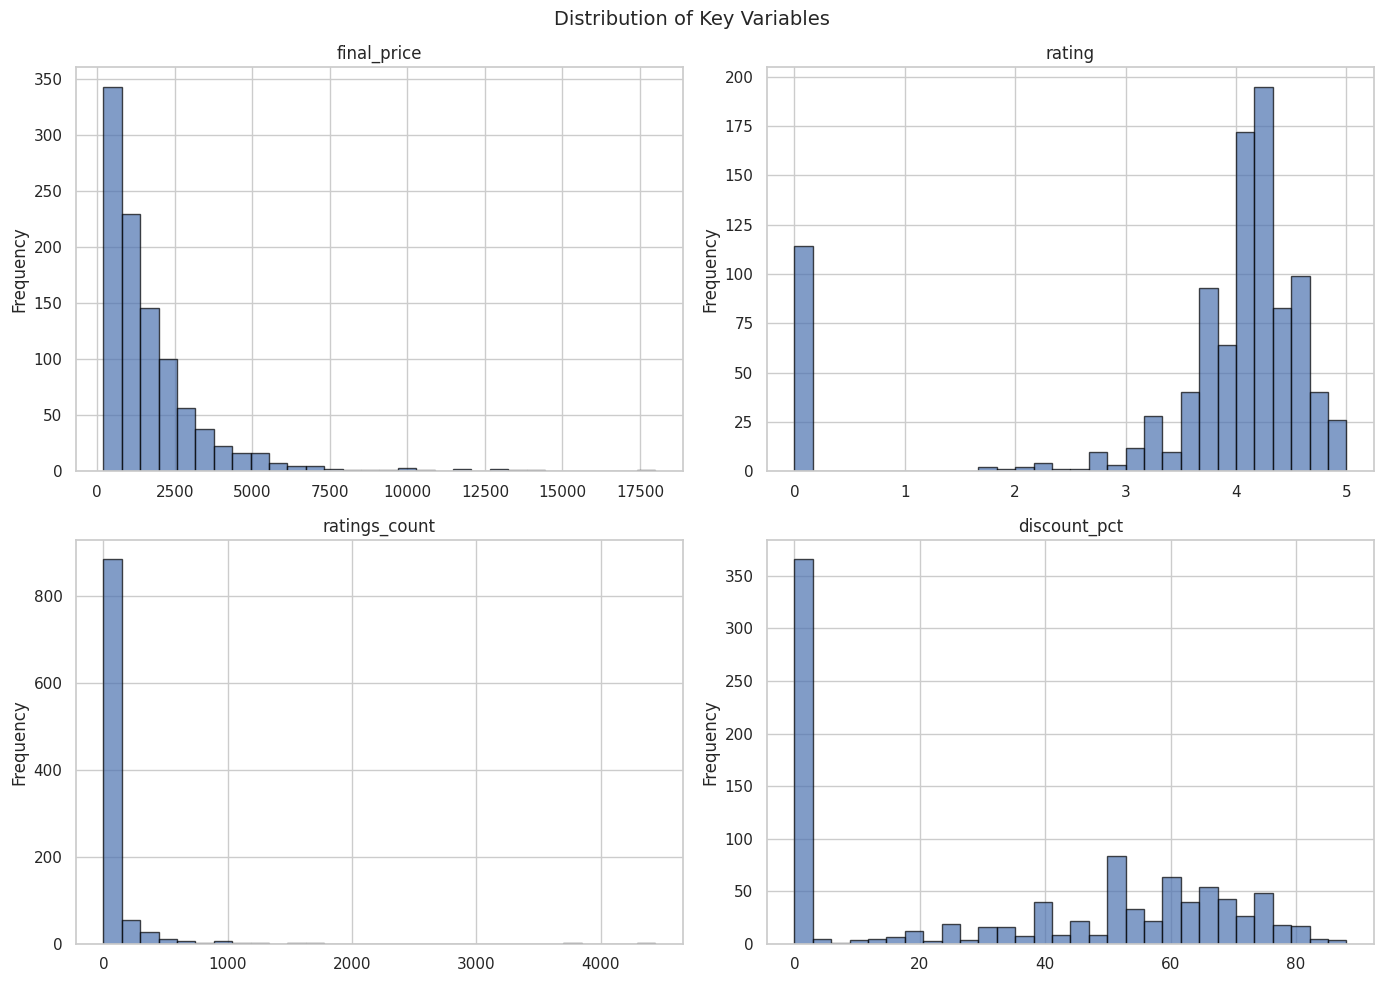

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Variables', fontsize=14)

vars_plot = ['final_price', 'rating', 'ratings_count', 'discount_pct']
for i, col in enumerate(vars_plot):
    if col in df.columns:
        ax = axes[i//2, i%2]
        df[col].dropna().hist(ax=ax, bins=30, edgecolor='black', alpha=0.7)
        ax.set_title(col)
        ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

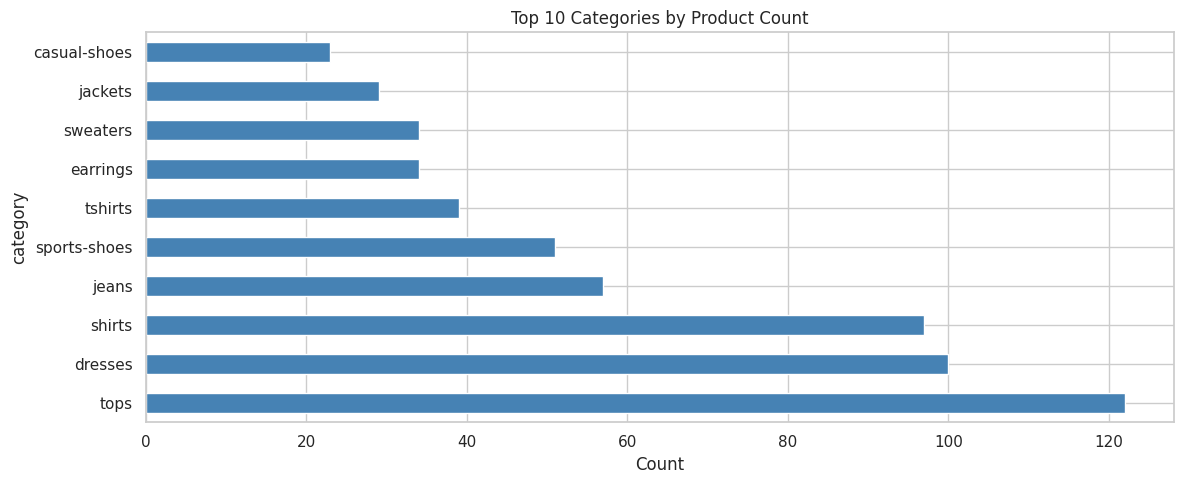

In [ ]:
if 'category' in df.columns:
    top_cats = df['category'].value_counts().head(10)
    plt.figure(figsize=(12, 5))
    top_cats.plot(kind='barh', color='steelblue')
    plt.title('Top 10 Categories by Product Count')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

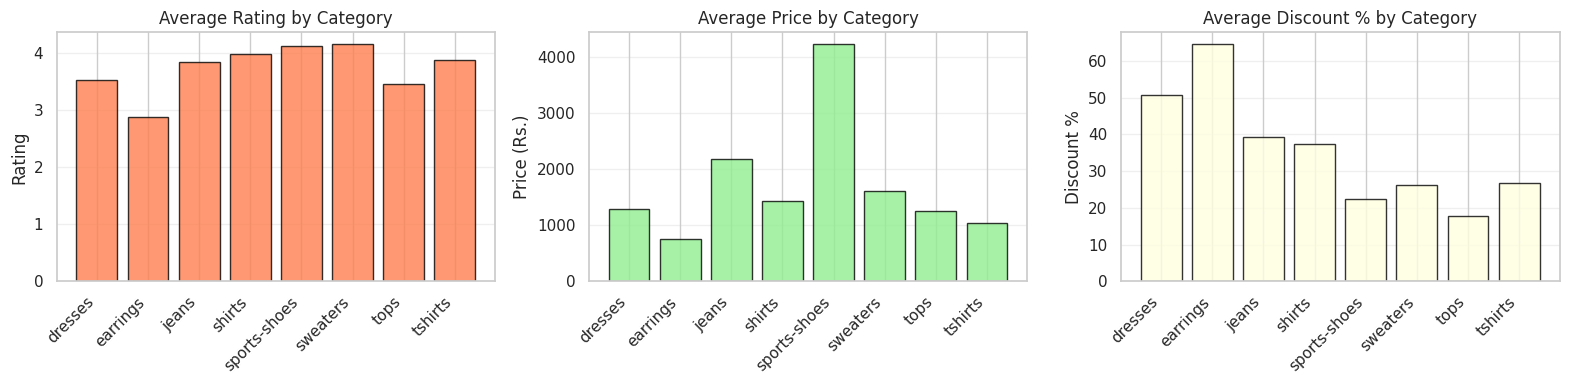

In [ ]:
if 'category' in df.columns and 'rating' in df.columns:
    top_cats = df['category'].value_counts().head(8).index
    df_cats = df[df['category'].isin(top_cats)].groupby('category').agg({
        'rating': 'mean',
        'final_price': 'mean',
        'discount_pct': 'mean'
    }).reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].bar(range(len(df_cats)), df_cats['rating'], color='coral', alpha=0.8, edgecolor='black')
    axes[0].set_xticks(range(len(df_cats)))
    axes[0].set_xticklabels(df_cats['category'], rotation=45, ha='right')
    axes[0].set_title('Average Rating by Category')
    axes[0].set_ylabel('Rating')
    axes[0].grid(True, alpha=0.3, axis='y')

    axes[1].bar(range(len(df_cats)), df_cats['final_price'], color='lightgreen', alpha=0.8, edgecolor='black')
    axes[1].set_xticks(range(len(df_cats)))
    axes[1].set_xticklabels(df_cats['category'], rotation=45, ha='right')
    axes[1].set_title('Average Price by Category')
    axes[1].set_ylabel('Price (Rs.)')
    axes[1].grid(True, alpha=0.3, axis='y')

    axes[2].bar(range(len(df_cats)), df_cats['discount_pct'], color='lightyellow', alpha=0.8, edgecolor='black')
    axes[2].set_xticks(range(len(df_cats)))
    axes[2].set_xticklabels(df_cats['category'], rotation=45, ha='right')
    axes[2].set_title('Average Discount % by Category')
    axes[2].set_ylabel('Discount %')
    axes[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

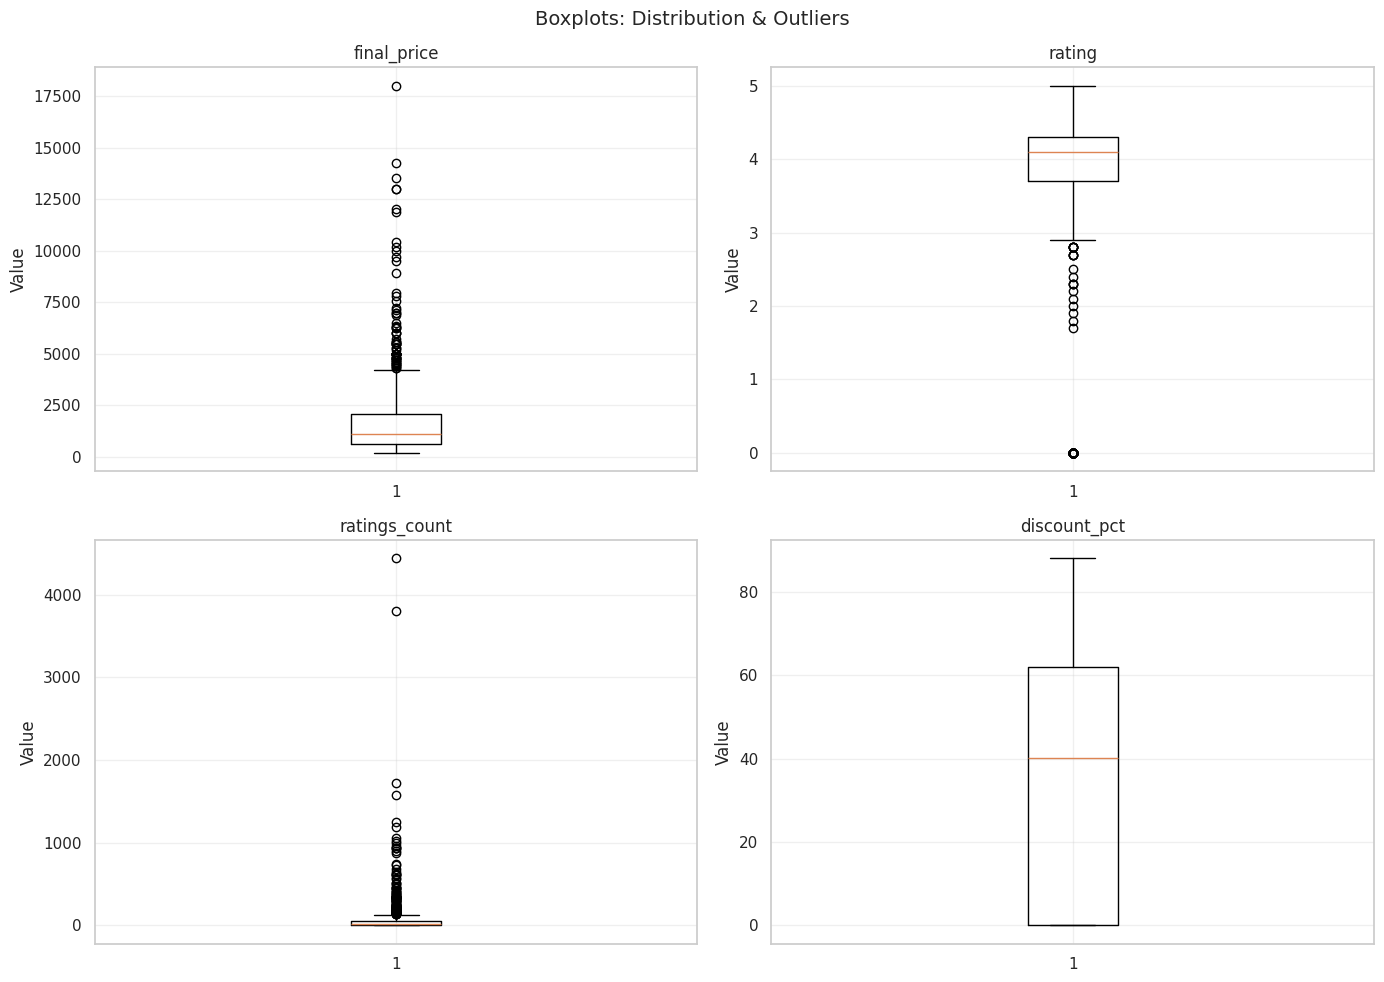

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Boxplots: Distribution & Outliers', fontsize=14)

vars_box = ['final_price', 'rating', 'ratings_count', 'discount_pct']
for i, col in enumerate(vars_box):
    if col in df.columns:
        ax = axes[i//2, i%2]
        data = df[col].dropna()
        ax.boxplot(data, vert=True)
        ax.set_title(col)
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

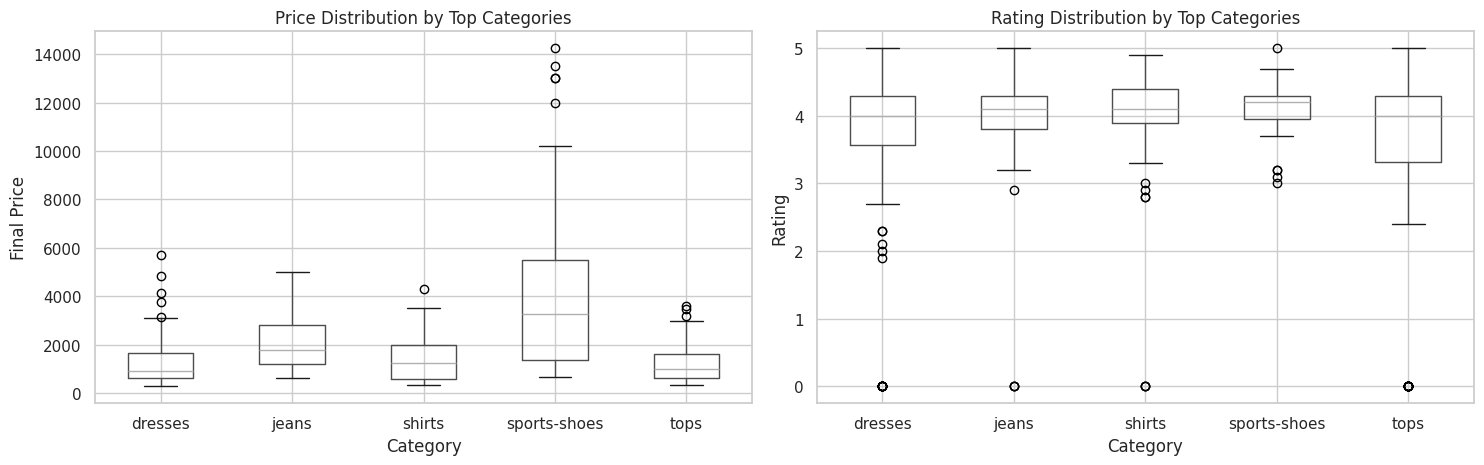

In [ ]:
if 'category' in df.columns and 'final_price' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    top_5_cats = df['category'].value_counts().head(5).index
    df_top = df[df['category'].isin(top_5_cats)]

    df_top.boxplot(column='final_price', by='category', ax=axes[0])
    axes[0].set_title('Price Distribution by Top Categories')
    axes[0].set_xlabel('Category')
    axes[0].set_ylabel('Final Price')

    if 'rating' in df.columns:
        df_top.boxplot(column='rating', by='category', ax=axes[1])
        axes[1].set_title('Rating Distribution by Top Categories')
        axes[1].set_xlabel('Category')
        axes[1].set_ylabel('Rating')

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

**Step 7:** Key Insights & Save Results

In [ ]:
print('='*60)
print('SUMMARY OF FINDINGS')
print('='*60)

if 'final_price' in df.columns:
    print(f'\n1. Average Product Price: Rs. {df["final_price"].mean():.0f}')

if 'rating' in df.columns:
    print(f'2. Average Product Rating: {df["rating"].mean():.2f}/5')

if 'discount_pct' in df.columns:
    avg_disc = df['discount_pct'].mean()
    print(f'3. Average Discount: {avg_disc:.1f}%')

if 'category' in df.columns:
    print(f'4. Total Categories: {df["category"].nunique()}')
    top_cat = df['category'].value_counts().index[0]
    print(f'5. Top Category: {top_cat}')

print(f'\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('='*60)

SUMMARY OF FINDINGS

1. Average Product Price: Rs. 1706
2. Average Product Rating: 3.62/5
3. Average Discount: 34.9%
4. Total Categories: 97
5. Top Category: tops

Dataset Shape: 1000 rows × 27 columns


In [ ]:
output_file = 'cleaned_dataset.csv'
df.reset_index(drop=True, inplace=True)
df.to_csv(output_file, index=False)
print(f'✓ Cleaned dataset saved: {output_file}')
print(f'  Rows: {len(df)}, Columns: {len(df.columns)}')

try:
    from google.colab import files
    files.download(output_file)
except:
    print(f'  Path: {os.path.abspath(output_file)}')

✓ Cleaned dataset saved: cleaned_dataset.csv
  Rows: 1000, Columns: 27


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>